<a href="https://colab.research.google.com/github/hisrinivas1972/Colab-Projects/blob/main/ipl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [ ]:
dataset = pd.read_csv("/content/drive/MyDrive/ipl/ipl_2022_dataset.csv")

In [ ]:
dataset.head()

,Unnamed: 0,Player,Base Price,TYPE,COST IN ₹ (CR.),Cost IN $ (000),2021 Squad,Team
0,0,Rashid Khan,Draft Pick,BOWLER,15.0,1950.0,SRH,Gujarat Titans
1,1,Hardik Pandya,Draft Pick,ALL-ROUNDER,15.0,1950.0,MI,Gujarat Titans
2,2,Lockie Ferguson,2 Cr,BOWLER,10.0,1300.0,KKR,Gujarat Titans
3,3,Rahul Tewatia,40 Lakh,ALL-ROUNDER,9.0,1170.0,RR,Gujarat Titans
4,4,Shubman Gill,Draft Pick,BATTER,8.0,1040.0,KKR,Gujarat Titans


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
dataset.shape # rows n columns

(633, 8)

In [ ]:
dataset.info() # data type

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 633 entries, 0 to 632
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       633 non-null    int64  
 1   Player           633 non-null    object 
 2   Base Price       633 non-null    object 
 3   TYPE             633 non-null    object 
 4   COST IN ₹ (CR.)  237 non-null    float64
 5   Cost IN $ (000)  237 non-null    float64
 6   2021 Squad       199 non-null    object 
 7   Team             633 non-null    object 
dtypes: float64(2), int64(1), object(5)
memory usage: 39.7+ KB


In [ ]:
dataset.columns

Index(['Unnamed: 0', 'Player', 'Base Price', 'TYPE', 'COST IN ₹ (CR.)',
       'Cost IN $ (000)', '2021 Squad', 'Team'],
      dtype='object')

In [ ]:
dataset.drop('Unnamed: 0', axis=1, inplace = True) # delete the column unnamed

In [ ]:
dataset.head()

,Player,Base Price,TYPE,COST IN ₹ (CR.),Cost IN $ (000),2021 Squad,Team
0,Rashid Khan,Draft Pick,BOWLER,15.0,1950.0,SRH,Gujarat Titans
1,Hardik Pandya,Draft Pick,ALL-ROUNDER,15.0,1950.0,MI,Gujarat Titans
2,Lockie Ferguson,2 Cr,BOWLER,10.0,1300.0,KKR,Gujarat Titans
3,Rahul Tewatia,40 Lakh,ALL-ROUNDER,9.0,1170.0,RR,Gujarat Titans
4,Shubman Gill,Draft Pick,BATTER,8.0,1040.0,KKR,Gujarat Titans


In [ ]:
dataset.isnull().sum() # find the null columns

Player               0
Base Price           0
TYPE                 0
COST IN ₹ (CR.)    396
Cost IN $ (000)    396
2021 Squad         434
Team                 0
dtype: int64

In [ ]:
dataset[dataset['Cost IN $ (000)'].isnull()] # find the null values in columns

,Player,Base Price,TYPE,COST IN ₹ (CR.),Cost IN $ (000),2021 Squad,Team
237,Suresh Raina,2 Cr,BATTER,NaN,NaN,CSK,Unsold
238,Steve Smith,2 Cr,BATTER,NaN,NaN,DC,Unsold
239,Shakib Al Hasan,2 Cr,ALL-ROUNDER,NaN,NaN,KKR,Unsold
240,Amit Mishra,1.5 Cr,BOWLER,NaN,NaN,DC,Unsold
241,Adil Rashid,2 Cr,BOWLER,NaN,NaN,PBKS,Unsold
...,...,...,...,...,...,...,...
628,Sairaj Patil,20 Lakh,BATTER,NaN,NaN,NaN,Unsold
629,Monu Singh,20 Lakh,BOWLER,NaN,NaN,NaN,Unsold
630,Nivethan Radhakrishnan,20 Lakh,BOWLER,NaN,NaN,NaN,Unsold
631,Lance Morris,20 Lakh,BOWLER,NaN,NaN,NaN,Unsold


In [ ]:
dataset['Cost IN $ (000)'] = dataset['Cost IN $ (000)'].fillna(0) # null values filled with 0
dataset['COST IN ₹ (CR.)'] = dataset['COST IN ₹ (CR.)'].fillna(0)

In [ ]:
dataset[dataset['2021 Squad'].isnull()] # unsold players list

,Player,Base Price,TYPE,COST IN ₹ (CR.),Cost IN $ (000),2021 Squad,Team
6,Yash Dayal,20 Lakh,BOWLER,3.2,416.0,NaN,Gujarat Titans
9,Abhinav Sadarangani,20 Lakh,BATTER,2.6,338.0,NaN,Gujarat Titans
10,Matthew Wade,2 Cr,WICKETKEEPER,2.4,312.0,NaN,Gujarat Titans
11,Alzarri Joseph,75 Lakh,BOWLER,2.4,312.0,NaN,Gujarat Titans
17,Varun Aaron,50 Lakh,BOWLER,0.5,65.0,NaN,Gujarat Titans
...,...,...,...,...,...,...,...
628,Sairaj Patil,20 Lakh,BATTER,0.0,0.0,NaN,Unsold
629,Monu Singh,20 Lakh,BOWLER,0.0,0.0,NaN,Unsold
630,Nivethan Radhakrishnan,20 Lakh,BOWLER,0.0,0.0,NaN,Unsold
631,Lance Morris,20 Lakh,BOWLER,0.0,0.0,NaN,Unsold


In [ ]:
dataset['2021 Squad'] = dataset['2021 Squad'].fillna('Not Participated') # null string values filled

In [ ]:
dataset.isnull().sum() # suscessfuly removed null values and filled what it is required

Player             0
Base Price         0
TYPE               0
COST IN ₹ (CR.)    0
Cost IN $ (000)    0
2021 Squad         0
Team               0
dtype: int64

In [ ]:
teams = dataset[dataset['COST IN ₹ (CR.)']>0]['Team'].unique() # COST IN ₹ (CR.) greated than 0 converting into unique
teams

array(['Gujarat Titans', 'Chennai Super Kings', 'Delhi Capitals',
       'Kolkata Knight Riders', 'Punjab Kings', 'Lucknow Super Giants',
       'Mumbai Indians', 'Royal Challengers Bangalore',
       'Rajasthan Royals', 'Sunrisers Hyderabad'], dtype=object)

In [ ]:
dataset['status'] = dataset['Team'].replace(teams,'sold') # creating new column status which is sold

In [ ]:
dataset.head()

,Player,Base Price,TYPE,COST IN ₹ (CR.),Cost IN $ (000),2021 Squad,Team,status
0,Rashid Khan,Draft Pick,BOWLER,15.0,1950.0,SRH,Gujarat Titans,sold
1,Hardik Pandya,Draft Pick,ALL-ROUNDER,15.0,1950.0,MI,Gujarat Titans,sold
2,Lockie Ferguson,2 Cr,BOWLER,10.0,1300.0,KKR,Gujarat Titans,sold
3,Rahul Tewatia,40 Lakh,ALL-ROUNDER,9.0,1170.0,RR,Gujarat Titans,sold
4,Shubman Gill,Draft Pick,BATTER,8.0,1040.0,KKR,Gujarat Titans,sold


In [ ]:
dataset

,Player,Base Price,TYPE,COST IN ₹ (CR.),Cost IN $ (000),2021 Squad,Team,status
0,Rashid Khan,Draft Pick,BOWLER,15.0,1950.0,SRH,Gujarat Titans,sold
1,Hardik Pandya,Draft Pick,ALL-ROUNDER,15.0,1950.0,MI,Gujarat Titans,sold
2,Lockie Ferguson,2 Cr,BOWLER,10.0,1300.0,KKR,Gujarat Titans,sold
3,Rahul Tewatia,40 Lakh,ALL-ROUNDER,9.0,1170.0,RR,Gujarat Titans,sold
4,Shubman Gill,Draft Pick,BATTER,8.0,1040.0,KKR,Gujarat Titans,sold
...,...,...,...,...,...,...,...,...
628,Sairaj Patil,20 Lakh,BATTER,0.0,0.0,Not Participated,Unsold,Unsold
629,Monu Singh,20 Lakh,BOWLER,0.0,0.0,Not Participated,Unsold,Unsold
630,Nivethan Radhakrishnan,20 Lakh,BOWLER,0.0,0.0,Not Participated,Unsold,Unsold
631,Lance Morris,20 Lakh,BOWLER,0.0,0.0,Not Participated,Unsold,Unsold


In [ ]:
dataset[dataset['Player'].duplicated(keep=False)]

,Player,Base Price,TYPE,COST IN ₹ (CR.),Cost IN $ (000),2021 Squad,Team,status
62,Lalit Yadav,20 Lakh,ALL-ROUNDER,0.65,84.5,DC,Delhi Capitals,sold
240,Amit Mishra,1.5 Cr,BOWLER,0.00,0.0,DC,Unsold,Unsold
499,Amit Mishra,20 Lakh,BOWLER,0.00,0.0,Not Participated,Unsold,Unsold
518,Shivam Sharma,20 Lakh,ALL-ROUNDER,0.00,0.0,Not Participated,Unsold,Unsold
530,Lalit Yadav,20 Lakh,BOWLER,0.00,0.0,Not Participated,Unsold,Unsold
537,Shubham Singh,20 Lakh,ALL-ROUNDER,0.00,0.0,Not Participated,Unsold,Unsold
544,Shubham Singh,20 Lakh,BOWLER,0.00,0.0,Not Participated,Unsold,Unsold
569,Shivam Sharma,20 Lakh,ALL-ROUNDER,0.00,0.0,Not Participated,Unsold,Unsold


In [ ]:
dataset.shape[0] # how many players have participated in 2022 IPL Auction?

633

In [ ]:
types = dataset['TYPE'].value_counts() # How many types of players have participated?
types.reset_index()

,index,TYPE
0,ALL-ROUNDER,242
1,BOWLER,215
2,BATTER,112
3,WICKETKEEPER,64


[]

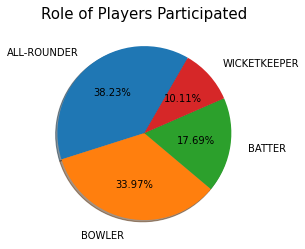

In [ ]:
plt.pie(types.values, labels=types.index, labeldistance=1.2,autopct='%1.2f%%', shadow=True, startangle=60)
plt.title('Role of Players Participated', fontsize =15)
plt.plot()

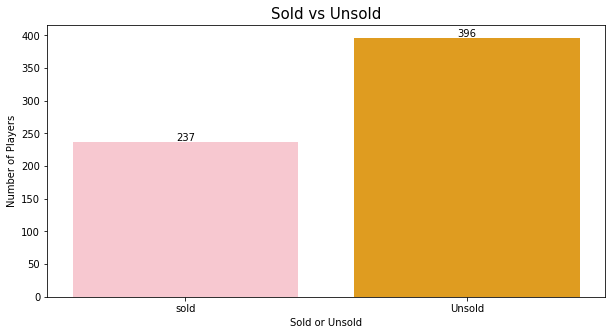

In [ ]:
# Players sold and unsold using a bar graph.

plt.figure(figsize=(10,5))
fig=sns.countplot(dataset['status'],palette=['Pink','Orange'])
plt.xlabel('Sold or Unsold')
plt.ylabel('Number of Players')
plt.title('Sold vs Unsold', fontsize=15)
plt.plot()

for p in fig.patches:
  fig.annotate(format(p.get_height(), '.0f'), (p.get_x() +
  p.get_width()/2., p.get_height()), ha = 'center', va = 'center',
  xytext = (0, 4), textcoords = 'offset points')

In [ ]:
dataset.groupby('status')['Player'].count()

status
Unsold    396
sold      237
Name: Player, dtype: int64

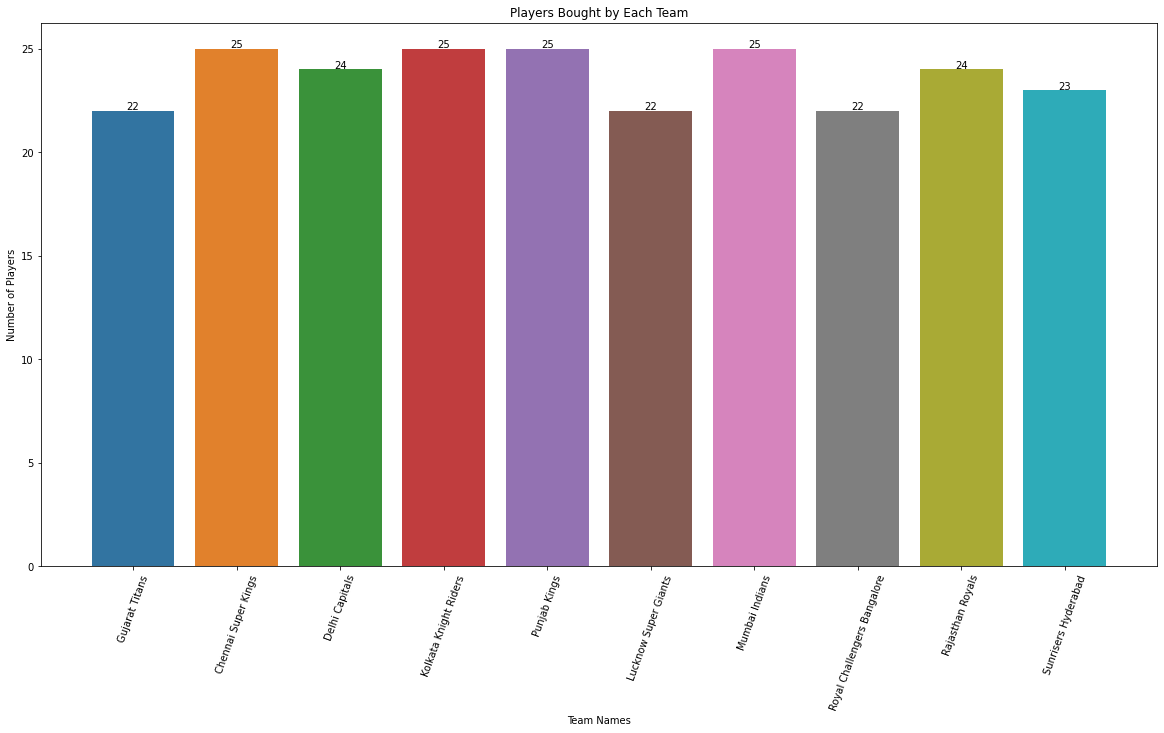

In [ ]:
# Total number of palyers bought by each team.

plt.figure(figsize=(20,10))
fig = sns.countplot(dataset[dataset['Team']!='Unsold']['Team'])
plt.xlabel('Team Names')
plt.ylabel('Number of Players')
plt.title('Players Bought by Each Team', fontsize=12)
plt.xticks(rotation=70)
plt.plot()

for p in fig.patches:
  fig.annotate(format(p.get_height(), '.0f'), (p.get_x() +
  p.get_width()/2., p.get_height()), ha = 'center', va = 'center', xytext = (0, 4),
  textcoords = 'offset points')

In [ ]:
dataset['retention'] = dataset['Base Price'] # New coloumn retention from base price

In [ ]:
dataset['retention'].replace(['2 Cr', '40 Lakh', '20 Lakh', '1 Cr', '75 Lakh', '50 Lakh', '30 lakh','1.5 Cr'], 'From Auction', inplace = True)

In [ ]:
# Treating Base price (Draft Pick became 0)

dataset['Base Price'].replace('Draft Pick',0, inplace = True)

In [ ]:
# 2 columns converting one is unit and one is value

dataset['base_price_unit'] = dataset['Base Price'].apply(lambda x: str(x).split(' ')[-1])
dataset['base_price'] = dataset['Base Price'].apply(lambda x: str(x).split(' ')[0])

In [ ]:
dataset['base_price'].replace('Retained', 0,inplace=True)

In [ ]:
dataset.head()

,Player,Base Price,TYPE,COST IN ₹ (CR.),Cost IN $ (000),2021 Squad,Team,status,retention,base_price_unit,base_price
0,Rashid Khan,0,BOWLER,15.0,1950.0,SRH,Gujarat Titans,sold,Draft Pick,0,0
1,Hardik Pandya,0,ALL-ROUNDER,15.0,1950.0,MI,Gujarat Titans,sold,Draft Pick,0,0
2,Lockie Ferguson,2 Cr,BOWLER,10.0,1300.0,KKR,Gujarat Titans,sold,From Auction,Cr,2
3,Rahul Tewatia,40 Lakh,ALL-ROUNDER,9.0,1170.0,RR,Gujarat Titans,sold,From Auction,Lakh,40
4,Shubman Gill,0,BATTER,8.0,1040.0,KKR,Gujarat Titans,sold,Draft Pick,0,0


In [ ]:
# Total players retained and bought

dataset.groupby(['Team','retention'])['retention'].count()[:-1]

Team                         retention   
Chennai Super Kings          30 Lakh          1
                             From Auction    20
                             Retained         4
Delhi Capitals               From Auction    20
                             Retained         4
Gujarat Titans               30 Lakh          1
                             Draft Pick       3
                             From Auction    18
Kolkata Knight Riders        30 Lakh          1
                             From Auction    20
                             Retained         4
Lucknow Super Giants         Draft Pick       3
                             From Auction    19
Mumbai Indians               30 Lakh          1
                             From Auction    20
                             Retained         4
Punjab Kings                 From Auction    23
                             Retained         2
Rajasthan Royals             30 Lakh          1
                             From Auction    2

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 <a list of 10 Text major ticklabel objects>)

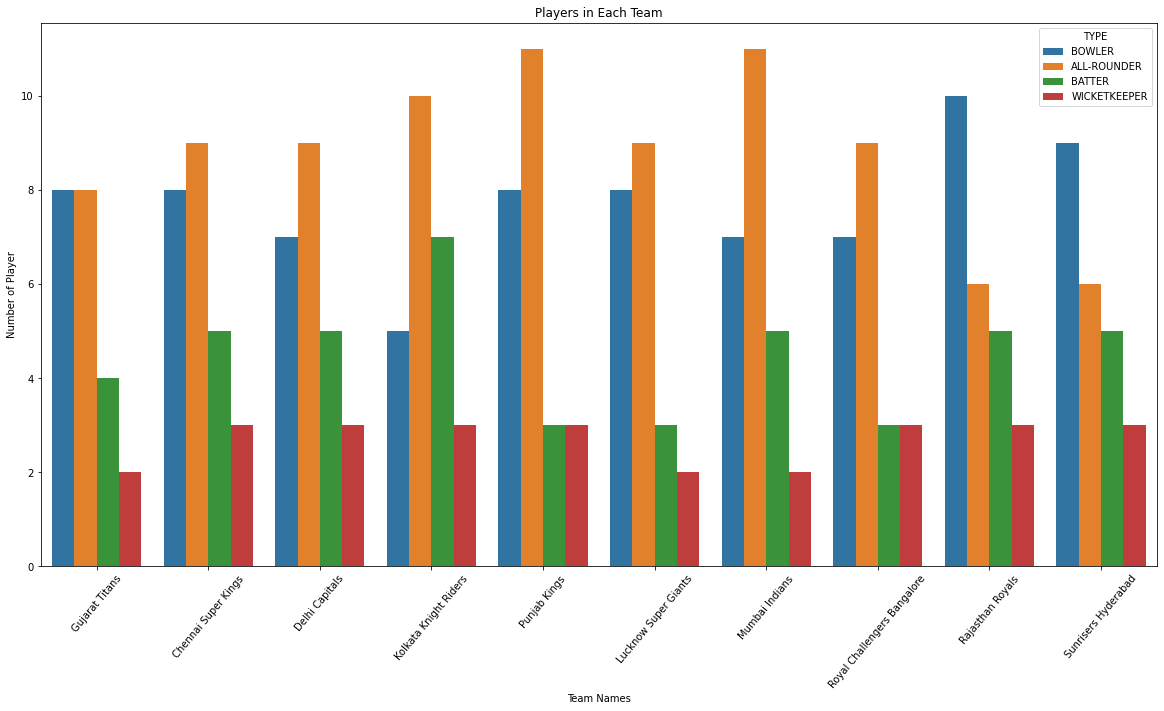

In [ ]:
plt.figure(figsize=(20,10))
fig = sns.countplot(dataset[dataset['Team']!='Unsold']['Team'],hue=dataset['TYPE'])
plt.title('Players in Each Team')
plt.xlabel('Team Names')
plt.ylabel('Number of Player')
plt.xticks(rotation=50)

In [ ]:
# Highest amount spent on a single player by each team

dataset[dataset['retention']=='From Auction'].groupby(['Team'])['COST IN ₹ (CR.)'].max()[:-1].sort_values(ascending = False)

Team
Mumbai Indians                 15.25
Chennai Super Kings            14.00
Kolkata Knight Riders          12.25
Punjab Kings                   11.50
Delhi Capitals                 10.75
Royal Challengers Bangalore    10.75
Sunrisers Hyderabad            10.75
Gujarat Titans                 10.00
Lucknow Super Giants           10.00
Rajasthan Royals               10.00
Name: COST IN ₹ (CR.), dtype: float64

In [ ]:
# Player reatined at maximum price.

dataset[dataset['retention']=='Retained'].sort_values(by = 'COST IN ₹ (CR.)', ascending=False).head(1)

,Player,Base Price,TYPE,COST IN ₹ (CR.),Cost IN $ (000),2021 Squad,Team,status,retention,base_price_unit,base_price
22,Ravindra Jadeja,Retained,ALL-ROUNDER,16.0,2080.0,CSK,Chennai Super Kings,sold,Retained,Retained,0


In [ ]:
# Top 5 Bowlers

dataset[(dataset['retention']=='From Auction') & (dataset['TYPE']=='BOWLER')].sort_values(by='COST IN ₹ (CR.)', ascending = False)

,Player,Base Price,TYPE,COST IN ₹ (CR.),Cost IN $ (000),2021 Squad,Team,status,retention,base_price_unit,base_price
23,Deepak Chahar,2 Cr,BOWLER,14.00,1820.0,CSK,Chennai Super Kings,sold,From Auction,Cr,2
48,Shardul Thakur,2 Cr,BOWLER,10.75,1397.5,CSK,Delhi Capitals,sold,From Auction,Cr,2
2,Lockie Ferguson,2 Cr,BOWLER,10.00,1300.0,KKR,Gujarat Titans,sold,From Auction,Cr,2
122,Avesh Khan,20 Lakh,BOWLER,10.00,1300.0,DC,Lucknow Super Giants,sold,From Auction,Lakh,20
192,Prasidh Krishna,1 Cr,BOWLER,10.00,1300.0,KKR,Rajasthan Royals,sold,From Auction,Cr,1
...,...,...,...,...,...,...,...,...,...,...,...
344,Taskin Ahmed,50 Lakh,BOWLER,0.00,0.0,Not Participated,Unsold,Unsold,From Auction,Lakh,50
326,Midhun Sudhesan,20 Lakh,BOWLER,0.00,0.0,Not Participated,Unsold,Unsold,From Auction,Lakh,20
324,Pardeep Sahu,20 Lakh,BOWLER,0.00,0.0,Not Participated,Unsold,Unsold,From Auction,Lakh,20
323,Prince Balwant Rai,20 Lakh,BOWLER,0.00,0.0,Not Participated,Unsold,Unsold,From Auction,Lakh,20


In [ ]:
dataset = dataset.rename(columns={'2021 Squad':'Prev_Team'}) # Not picked this year
dataset

,Player,Base Price,TYPE,COST IN ₹ (CR.),Cost IN $ (000),Prev_Team,Team,status,retention,base_price_unit,base_price
0,Rashid Khan,0,BOWLER,15.0,1950.0,SRH,Gujarat Titans,sold,Draft Pick,0,0
1,Hardik Pandya,0,ALL-ROUNDER,15.0,1950.0,MI,Gujarat Titans,sold,Draft Pick,0,0
2,Lockie Ferguson,2 Cr,BOWLER,10.0,1300.0,KKR,Gujarat Titans,sold,From Auction,Cr,2
3,Rahul Tewatia,40 Lakh,ALL-ROUNDER,9.0,1170.0,RR,Gujarat Titans,sold,From Auction,Lakh,40
4,Shubman Gill,0,BATTER,8.0,1040.0,KKR,Gujarat Titans,sold,Draft Pick,0,0
...,...,...,...,...,...,...,...,...,...,...,...
628,Sairaj Patil,20 Lakh,BATTER,0.0,0.0,Not Participated,Unsold,Unsold,From Auction,Lakh,20
629,Monu Singh,20 Lakh,BOWLER,0.0,0.0,Not Participated,Unsold,Unsold,From Auction,Lakh,20
630,Nivethan Radhakrishnan,20 Lakh,BOWLER,0.0,0.0,Not Participated,Unsold,Unsold,From Auction,Lakh,20
631,Lance Morris,20 Lakh,BOWLER,0.0,0.0,Not Participated,Unsold,Unsold,From Auction,Lakh,20


In [ ]:
unsold_players = dataset[(dataset.Prev_Team != 'Not Participated')
  & (dataset.Team == 'Unsold')][['Player','Prev_Team']]


In [ ]:
print(unsold_players)

                      Player Prev_Team
237             Suresh Raina       CSK
238              Steve Smith        DC
239          Shakib Al Hasan       KKR
240              Amit Mishra        DC
241              Adil Rashid      PBKS
242              Imran Tahir       CSK
243            Mujeeb Zadran       SRH
244               Adam Zampa       RCB
245            Rajat Patidar       RCB
246     Mohammed Azharuddeen       RCB
249             M. Siddharth        DC
252              Dawid Malan      PBKS
253              Eoin Morgan       KKR
254        Cheteshwar Pujara       CSK
255           Saurabh Tiwary        MI
257            Ishant Sharma        DC
259            Piyush Chawla        MI
260           Tabraiz Shamsi        RR
262              Sachin Baby       RCB
267              Virat Singh       SRH
269              Akash Singh        RR
273               Chris Lynn        MI
276            George Garton       RCB
288               Andrew Tye        RR
289          Sandeep Warr

In [ ]:
sold_players = dataset[(dataset.Prev_Team != 'Not Participated')
  & (dataset.status == 'sold')][['Player','Team']]


In [ ]:
print(sold_players)

                 Player                 Team
0           Rashid Khan       Gujarat Titans
1         Hardik Pandya       Gujarat Titans
2       Lockie Ferguson       Gujarat Titans
3         Rahul Tewatia       Gujarat Titans
4          Shubman Gill       Gujarat Titans
..                  ...                  ...
228      Glenn Phillips  Sunrisers Hyderabad
229       Shreyas Gopal  Sunrisers Hyderabad
230        Vishnu Vinod  Sunrisers Hyderabad
232         Priyam Garg  Sunrisers Hyderabad
234  Jagadeesha Suchith  Sunrisers Hyderabad

[159 rows x 2 columns]


In [ ]:
gb = sold_players.groupby('Team')

In [ ]:
gb.first()

,Player
Team,
Chennai Super Kings,Ravindra Jadeja
Delhi Capitals,Rishabh Pant
Gujarat Titans,Rashid Khan
Kolkata Knight Riders,Shreyas Iyer
Lucknow Super Giants,KL Rahul
Mumbai Indians,Rohit Sharma
Punjab Kings,Mayank Agarwal
Rajasthan Royals,Sanju Samson
Royal Challengers Bangalore,Virat Kohli
